# Transformer-中英文翻译；

In [23]:
import os;
import re;
import math;
import time;
import random;
import warnings;
warnings.filterwarnings('ignore');

import numpy as np;
import pandas as pd;
import matplotlib.pyplot as plt;

import torch;
import torch.nn as nn;
import torch.optim as optim;
from torch.utils.data import Dataset, DataLoader;
from torch.nn.utils.rnn import pad_sequence;

from collections import Counter;
from typing import List, Tuple, Dict;

# 设置随机种子保证可复现性。
SEED = 42;
random.seed(SEED);
np.random.seed(SEED);
torch.manual_seed(SEED);
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED);

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu');
print(f"使用设备: {device} ！");
if torch.cuda.is_available():
    print(f"GPU数量: {torch.cuda.device_count()} ！");
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)} ！");

使用设备: cuda ！
GPU数量: 2 ！
GPU 0: Tesla T4 ！
GPU 1: Tesla T4 ！


In [24]:
DATA_PATH = '/kaggle/input/datasets/ailananjuxi/ttdata/data.csv';
MODEL_SAVE_PATH = './transformer_model.pt';

# 模型超参数设置。
EMBEDDING_DIM = 256;        # 词嵌入维度。
NUM_HEADS = 4;              # 多头注意力头数。
NUM_ENCODER_LAYERS = 2;     # 编码器层数。
NUM_DECODER_LAYERS = 2;     # 解码器层数。
FEEDFORWARD_DIM = 512;     # 前馈网络隐藏层维度。
DROPOUT_RATE = 0.2;         # Dropout比率。

# 训练超参数设置。
BATCH_SIZE = 128;            # 批次大小，根据GPU显存调整。
LEARNING_RATE = 0.0001;     # 学习率。
NUM_EPOCHS = 15;            # 训练轮数。
CLIP_GRADIENT = 1.0;        # 梯度裁剪阈值。

# 词汇表相关设置。
MIN_FREQ = 2;               # 最小词频，低于此值的词将被过滤。
MAX_SEQ_LENGTH = 100;       # 最大序列长度。

# 特殊标记定义。
PAD_TOKEN = '<pad>';        # 填充标记。
SOS_TOKEN = '<sos>';        # 句子开始标记。
EOS_TOKEN = '<eos>';        # 句子结束标记。
UNK_TOKEN = '<unk>';        # 未知词标记。

# 是否继续训练模式。
CONTINUE_TRAIN = False;     # 设置为True则从保存的模型继续训练。

print("✅常量定义完成！");

✅常量定义完成！


## 数据准备：

In [25]:
class Vocabulary:
    """词汇表类，用于构建和管理源语言和目标语言的词汇表。"""
    
    def __init__(self):
        self.word2idx = {PAD_TOKEN: 0, SOS_TOKEN: 1, EOS_TOKEN: 2, UNK_TOKEN: 3};
        self.idx2word = {0: PAD_TOKEN, 1: SOS_TOKEN, 2: EOS_TOKEN, 3: UNK_TOKEN};
        self.word_count = {};
        self.n_words = 4;  # 初始包含4个特殊标记。
    
    def add_sentence(self, sentence: str):
        """将句子中的每个词添加到词汇表。"""
        for word in sentence.split():
            self.add_word(word);
    
    def add_word(self, word: str):
        """添加单个词到词汇表。"""
        if word not in self.word_count:
            self.word_count[word] = 1;
        else:
            self.word_count[word] += 1;
        
        if word not in self.word2idx and self.word_count[word] >= MIN_FREQ:
            self.word2idx[word] = self.n_words;
            self.idx2word[self.n_words] = word;
            self.n_words += 1;
    
    def sentence_to_indices(self, sentence: str) -> List[int]:
        """将句子转换为索引序列。"""
        indices = [self.word2idx.get(word, self.word2idx[UNK_TOKEN]) for word in sentence.split()];
        return indices;
    
    def indices_to_sentence(self, indices: List[int]) -> str:
        """将索引序列转换为句子。"""
        words = [self.idx2word.get(idx, UNK_TOKEN) for idx in indices if idx != self.word2idx[PAD_TOKEN]];
        return ' '.join(words);


def clean_english_text(text: str) -> str:
    """清洗英文文本，去除多余空格和特殊字符。"""
    text = text.lower().strip();
    text = re.sub(r"[^a-zA-Z0-9?.!,¿]+", " ", text);
    text = re.sub(r"[ ]+", " ", text);
    return text;


def clean_chinese_text(text: str) -> str:
    """清洗中文文本，在汉字之间添加空格以便分词。"""
    text = text.strip();
    # 在中文字符之间添加空格。
    text = ' '.join(list(text));
    return text;


def load_data(file_path: str) -> Tuple[List[str], List[str]]:
    """从CSV文件加载中英文平行语料。"""
    print(f"正在加载数据: {file_path} ！");
    
    df = pd.read_csv(file_path, header=None, names=['english', 'chinese', 'license']);
    
    english_sentences = [];
    chinese_sentences = [];
    
    for idx, row in df.iterrows():
        en_text = clean_english_text(str(row['english']));
        zh_text = clean_chinese_text(str(row['chinese']));
        
        # 过滤过短的句子。
        if len(en_text.split()) > 0 and len(zh_text.split()) > 0:
            english_sentences.append(en_text);
            chinese_sentences.append(zh_text);
    
    print(f"共加载 {len(english_sentences)} 条平行语料 ！");
    return english_sentences, chinese_sentences;


def build_vocabularies(english_sentences: List[str], chinese_sentences: List[str]) -> Tuple[Vocabulary, Vocabulary]:
    """构建英文和中文的词汇表。"""
    print("正在构建词汇表 ！");
    
    en_vocab = Vocabulary();
    zh_vocab = Vocabulary();
    
    for en_sent, zh_sent in zip(english_sentences, chinese_sentences):
        en_vocab.add_sentence(en_sent);
        zh_vocab.add_sentence(zh_sent);
    
    print(f"英文词汇表大小: {en_vocab.n_words} ！");
    print(f"中文词汇表大小: {zh_vocab.n_words} ！");
    
    return en_vocab, zh_vocab;


class TranslationDataset(Dataset):
    """翻译数据集类，用于PyTorch的DataLoader。"""
    
    def __init__(self, english_sentences: List[str], chinese_sentences: List[str], 
                 en_vocab: Vocabulary, zh_vocab: Vocabulary):
        self.english_sentences = english_sentences;
        self.chinese_sentences = chinese_sentences;
        self.en_vocab = en_vocab;
        self.zh_vocab = zh_vocab;
    
    def __len__(self):
        return len(self.english_sentences);
    
    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        en_sent = self.english_sentences[idx];
        zh_sent = self.chinese_sentences[idx];
        
        # 将句子转换为索引序列，并添加SOS和EOS标记。
        en_indices = [self.en_vocab.word2idx[SOS_TOKEN]] + \
                     self.en_vocab.sentence_to_indices(en_sent) + \
                     [self.en_vocab.word2idx[EOS_TOKEN]];
        
        zh_indices = [self.zh_vocab.word2idx[SOS_TOKEN]] + \
                     self.zh_vocab.sentence_to_indices(zh_sent) + \
                     [self.zh_vocab.word2idx[EOS_TOKEN]];
        
        return torch.tensor(en_indices, dtype=torch.long), \
               torch.tensor(zh_indices, dtype=torch.long);


def collate_fn(batch: List[Tuple[torch.Tensor, torch.Tensor]]) -> Tuple[torch.Tensor, torch.Tensor]:
    """自定义的批次处理函数，用于对序列进行填充。"""
    src_batch, tgt_batch = zip(*batch);
    
    # 对源序列和目标序列分别进行填充。
    src_batch = pad_sequence(src_batch, batch_first=True, padding_value=0);
    tgt_batch = pad_sequence(tgt_batch, batch_first=True, padding_value=0);
    
    return src_batch, tgt_batch;

In [26]:
english_sentences, chinese_sentences = load_data(DATA_PATH);

print("\n样本数据展示:");
for i in range(min(5, len(english_sentences))):
    print(f"英文: {english_sentences[i]}");
    print(f"中文: {chinese_sentences[i]}");
    print("-" * 40);

# 构建词汇表。
en_vocab, zh_vocab = build_vocabularies(english_sentences, chinese_sentences);

dataset = TranslationDataset(english_sentences, chinese_sentences, en_vocab, zh_vocab);
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn);

print(f"数据集批次数量: {len(dataloader)} ！");

正在加载数据: /kaggle/input/datasets/ailananjuxi/ttdata/data.csv ！
共加载 60321 条平行语料 ！

样本数据展示:
英文: hi.
中文: 嗨 。
----------------------------------------
英文: hi.
中文: 你 好 。
----------------------------------------
英文: run.
中文: 你 用 跑 的 。
----------------------------------------
英文: stop!
中文: 住 手 ！
----------------------------------------
英文: wait!
中文: 等 等 ！
----------------------------------------
正在构建词汇表 ！
英文词汇表大小: 13051 ！
中文词汇表大小: 3028 ！
数据集批次数量: 472 ！


## 模型：

In [27]:
class PositionalEncoding(nn.Module):
    """位置编码层，为输入序列添加位置信息。"""
    
    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 5000):
        super(PositionalEncoding, self).__init__();
        self.dropout = nn.Dropout(p=dropout);
        
        # 计算位置编码。
        pe = torch.zeros(max_len, d_model);
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1);
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model));
        
        pe[:, 0::2] = torch.sin(position * div_term);
        pe[:, 1::2] = torch.cos(position * div_term);
        pe = pe.unsqueeze(0).transpose(0, 1);
        
        self.register_buffer('pe', pe);
    
    def forward(self, x):
        x = x + self.pe[:x.size(0), :];
        return self.dropout(x);


class TransformerModel(nn.Module):
    """Transformer翻译模型，包含编码器和解码器。"""
    
    def __init__(self, src_vocab_size: int, tgt_vocab_size: int, 
                 d_model: int = 512, nhead: int = 8, 
                 num_encoder_layers: int = 6, num_decoder_layers: int = 6,
                 dim_feedforward: int = 2048, dropout: float = 0.1):
        super(TransformerModel, self).__init__();
        
        self.d_model = d_model;
        
        # 源语言和目标语言的词嵌入层。
        self.src_embedding = nn.Embedding(src_vocab_size, d_model);
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, d_model);
        
        # 位置编码层。
        self.pos_encoder = PositionalEncoding(d_model, dropout);
        
        # Transformer模型主体。
        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        );
        
        # 输出层，将解码器输出映射到目标词汇表。
        self.output_layer = nn.Linear(d_model, tgt_vocab_size);
        
        self._init_parameters();
    
    def _init_parameters(self):
        """初始化模型参数。"""
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p);
    
    def make_src_mask(self, src):
        """创建源序列的填充掩码。"""
        src_mask = (src == 0);  # PAD_TOKEN的索引为0。
        return src_mask;
    
    def make_tgt_mask(self, tgt):
        """创建目标序列的掩码（填充掩码 + 因果掩码）。"""
        tgt_pad_mask = (tgt == 0);
        tgt_len = tgt.size(1);
        tgt_subsequent_mask = torch.triu(torch.ones(tgt_len, tgt_len), diagonal=1).bool().to(tgt.device);
        return tgt_pad_mask, tgt_subsequent_mask;
    
    def forward(self, src, tgt):
        # 对输入进行嵌入和缩放。
        src_emb = self.src_embedding(src) * math.sqrt(self.d_model);
        tgt_emb = self.tgt_embedding(tgt) * math.sqrt(self.d_model);
        
        # 添加位置编码。
        src_emb = self.pos_encoder(src_emb.transpose(0, 1)).transpose(0, 1);
        tgt_emb = self.pos_encoder(tgt_emb.transpose(0, 1)).transpose(0, 1);
        
        # 创建掩码。
        src_mask = self.make_src_mask(src);
        tgt_pad_mask, tgt_subsequent_mask = self.make_tgt_mask(tgt);
        
        # Transformer前向传播。
        output = self.transformer(
            src_emb, tgt_emb,
            src_key_padding_mask=src_mask,
            tgt_key_padding_mask=tgt_pad_mask,
            tgt_mask=tgt_subsequent_mask,
            memory_key_padding_mask=src_mask
        );
        
        # 映射到目标词汇表。
        output = self.output_layer(output);
        return output;
    
    def translate(self, src, max_len: int = 50):# 翻译函数。
        self.eval();
        with torch.no_grad():
            batch_size = src.size(0);
            tgt = torch.ones(batch_size, 1).fill_(1).long().to(src.device);  # SOS_TOKEN索引为1。
            
            for _ in range(max_len):
                output = self.forward(src, tgt);
                next_word = output[:, -1, :].argmax(dim=-1, keepdim=True);
                tgt = torch.cat([tgt, next_word], dim=1);
                
                # 如果所有序列都生成了EOS_TOKEN，则停止。
                if (next_word == 2).all():  # EOS_TOKEN索引为2。
                    break;
            
            return tgt;

In [28]:
# 初始化模型。
model = TransformerModel(
    src_vocab_size=en_vocab.n_words,
    tgt_vocab_size=zh_vocab.n_words,
    d_model=EMBEDDING_DIM,
    nhead=NUM_HEADS,
    num_encoder_layers=NUM_ENCODER_LAYERS,
    num_decoder_layers=NUM_DECODER_LAYERS,
    dim_feedforward=FEEDFORWARD_DIM,
    dropout=DROPOUT_RATE
).to(device);

# 多GPU支持。
if torch.cuda.device_count() > 1:
    print(f"使用 {torch.cuda.device_count()} 个GPU进行训练 ！");
    model = nn.DataParallel(model);

print(f"模型参数量: {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M ！");

使用 2 个GPU进行训练 ！
模型参数量: 7.53M ！


## 训练：

In [29]:
# 定义损失函数和优化器。
criterion = nn.CrossEntropyLoss(ignore_index=0);  # 忽略PAD_TOKEN的损失。
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, betas=(0.9, 0.98), eps=1e-9);
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3);

if torch.cuda.device_count() > 1:
    BATCH_SIZE = BATCH_SIZE * torch.cuda.device_count();
    print(f"多GPU环境下调整批次大小为: {BATCH_SIZE} ！");

if CONTINUE_TRAIN and os.path.exists(MODEL_SAVE_PATH):
    print(f"从已有模型继续训练: {MODEL_SAVE_PATH} ！");
    checkpoint = torch.load(MODEL_SAVE_PATH, map_location=device);
    
    if torch.cuda.device_count() > 1:
        model.module.load_state_dict(checkpoint['model_state_dict']);
    else:
        model.load_state_dict(checkpoint['model_state_dict']);
    
    optimizer.load_state_dict(checkpoint['optimizer_state_dict']);
    start_epoch = checkpoint['epoch'] + 1;
    best_loss = checkpoint['loss'];
    print(f"从第 {start_epoch} 轮继续训练，上次最佳损失: {best_loss:.4f} ！");


def train_epoch(model, dataloader, criterion, optimizer, device):
    """训练一个epoch。"""
    model.train();
    epoch_loss = 0;
    
    for batch_idx, (src, tgt) in enumerate(dataloader):
        src = src.to(device);
        tgt = tgt.to(device);
        
        # 目标输入是tgt去掉最后一个词，目标输出是tgt去掉第一个词。
        tgt_input = tgt[:, :-1];
        tgt_output = tgt[:, 1:];
        
        optimizer.zero_grad();
        
        # 前向传播。
        output = model(src, tgt_input);
        
        # 计算损失。
        output_dim = output.shape[-1];
        output = output.contiguous().view(-1, output_dim);
        tgt_output = tgt_output.contiguous().view(-1);
        
        loss = criterion(output, tgt_output);
        
        # 反向传播。
        loss.backward();
        
        # 梯度裁剪。
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_GRADIENT);
        
        optimizer.step();
        
        epoch_loss += loss.item();
        
        # 每100个批次打印一次进度。
        if (batch_idx + 1) % 100 == 0:
            print(f"  批次 [{batch_idx+1}/{len(dataloader)}], 损失: {loss.item():.4f} ！");
    
    return epoch_loss / len(dataloader);


def evaluate(model, dataloader, criterion, device):
    """评估模型。"""
    model.eval();
    epoch_loss = 0;
    
    with torch.no_grad():
        for src, tgt in dataloader:
            src = src.to(device);
            tgt = tgt.to(device);
            
            tgt_input = tgt[:, :-1];
            tgt_output = tgt[:, 1:];
            
            output = model(src, tgt_input);
            
            output_dim = output.shape[-1];
            output = output.contiguous().view(-1, output_dim);
            tgt_output = tgt_output.contiguous().view(-1);
            
            loss = criterion(output, tgt_output);
            epoch_loss += loss.item();
    
    return epoch_loss / len(dataloader);


# 划分训练集和验证集。
train_size = int(0.9 * len(dataset));
val_size = len(dataset) - train_size;
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size]);

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn);
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn);

print(f"训练集大小: {len(train_dataset)} ！");
print(f"验证集大小: {len(val_dataset)} ！");

多GPU环境下调整批次大小为: 256 ！
训练集大小: 54288 ！
验证集大小: 6033 ！


In [30]:
%%time

# 检查是否需要从已有模型继续训练。
start_epoch = 0;
best_loss = float('inf');

print("\n开始训练 ！");
train_losses = [];
val_losses = [];

for epoch in range(start_epoch, NUM_EPOCHS):
    start_time = time.time();
    
    print(f"\n第 {epoch+1}/{NUM_EPOCHS} 轮训练开始 ！");
    
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device);
    val_loss = evaluate(model, val_loader, criterion, device);
    
    scheduler.step(val_loss);
    
    end_time = time.time();
    epoch_mins, epoch_secs = divmod(int(end_time - start_time), 60);
    
    train_losses.append(train_loss);
    val_losses.append(val_loss);
    
    print(f"第 {epoch+1} 轮完成，耗时: {epoch_mins}分{epoch_secs}秒 ！");
    print(f"训练损失: {train_loss:.4f} | 验证损失: {val_loss:.4f} ！");
    
    # 保存最佳模型。
    if val_loss < best_loss:
        best_loss = val_loss;
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.module.state_dict() if torch.cuda.device_count() > 1 else model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': val_loss,
            'en_vocab': en_vocab,
            'zh_vocab': zh_vocab
        };
        torch.save(checkpoint, MODEL_SAVE_PATH);
        print(f"✅ 模型已保存，验证损失: {val_loss:.4f} ！");

print("——"*50);
print("✅训练完成！");
print("——"*50);


开始训练 ！

第 1/15 轮训练开始 ！
  批次 [100/213], 损失: 5.5684 ！
  批次 [200/213], 损失: 4.9807 ！
第 1 轮完成，耗时: 0分22秒 ！
训练损失: 5.7693 | 验证损失: 4.8011 ！
✅ 模型已保存，验证损失: 4.8011 ！

第 2/15 轮训练开始 ！
  批次 [100/213], 损失: 4.5959 ！
  批次 [200/213], 损失: 4.2122 ！
第 2 轮完成，耗时: 0分22秒 ！
训练损失: 4.5940 | 验证损失: 4.1434 ！
✅ 模型已保存，验证损失: 4.1434 ！

第 3/15 轮训练开始 ！
  批次 [100/213], 损失: 3.9700 ！
  批次 [200/213], 损失: 4.0631 ！
第 3 轮完成，耗时: 0分22秒 ！
训练损失: 4.1154 | 验证损失: 3.7684 ！
✅ 模型已保存，验证损失: 3.7684 ！

第 4/15 轮训练开始 ！
  批次 [100/213], 损失: 3.7162 ！
  批次 [200/213], 损失: 3.7485 ！
第 4 轮完成，耗时: 0分22秒 ！
训练损失: 3.7948 | 验证损失: 3.4941 ！
✅ 模型已保存，验证损失: 3.4941 ！

第 5/15 轮训练开始 ！
  批次 [100/213], 损失: 3.4883 ！
  批次 [200/213], 损失: 3.2809 ！
第 5 轮完成，耗时: 0分22秒 ！
训练损失: 3.5524 | 验证损失: 3.2698 ！
✅ 模型已保存，验证损失: 3.2698 ！

第 6/15 轮训练开始 ！
  批次 [100/213], 损失: 3.2643 ！
  批次 [200/213], 损失: 3.2552 ！
第 6 轮完成，耗时: 0分22秒 ！
训练损失: 3.3455 | 验证损失: 3.0914 ！
✅ 模型已保存，验证损失: 3.0914 ！

第 7/15 轮训练开始 ！
  批次 [100/213], 损失: 3.2399 ！
  批次 [200/213], 损失: 3.0069 ！
第 7 轮完成，耗时: 0分22秒 ！
训练损失: 3.1711 | 验

## 测试：

加载最佳模型进行测试 ！
模型加载成功 ！

翻译测试结果:
英文: Hello!
中文: 你好吗？
------------------------------------------------------------
英文: How are you?
中文: 你怎么样？
------------------------------------------------------------
英文: Thank you very much.
中文: 谢谢你很多。
------------------------------------------------------------
英文: I love you.
中文: 我爱你。
------------------------------------------------------------
英文: Good morning!
中文: 好好运动。
------------------------------------------------------------
英文: What is your name?
中文: 你的名字是什么？
------------------------------------------------------------
英文: Nice to meet you.
中文: 很好见你。
------------------------------------------------------------
英文: See you later.
中文: 看见你。
------------------------------------------------------------
英文: Have a good day!
中文: 有好好好吗？
------------------------------------------------------------
英文: I am learning Chinese.
中文: 我学校。
------------------------------------------------------------

训练曲线已保存到 training_curve.png ！
————————————————————————————

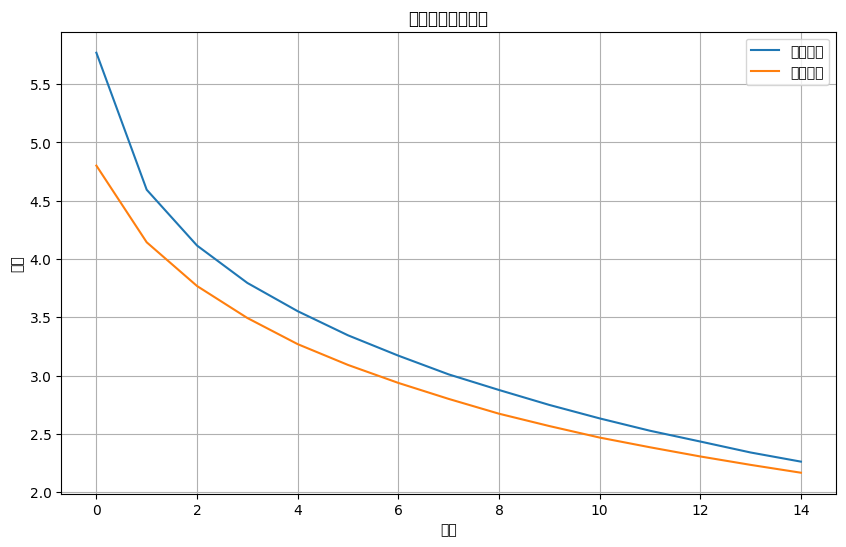

In [33]:
# 加载最佳模型进行测试。
if os.path.exists(MODEL_SAVE_PATH):
    print("加载最佳模型进行测试 ！");
    checkpoint = torch.load(MODEL_SAVE_PATH, map_location=device, weights_only=False);
    
    if torch.cuda.device_count() > 1:
        model.module.load_state_dict(checkpoint['model_state_dict']);
    else:
        model.load_state_dict(checkpoint['model_state_dict']);
    
    print("模型加载成功 ！");


def translate_sentence(model, sentence: str, en_vocab: Vocabulary, zh_vocab: Vocabulary, device):
    """翻译单个句子。"""
    model.eval();
    
    # 清洗和预处理输入句子。
    sentence = clean_english_text(sentence);
    src_indices = [en_vocab.word2idx[SOS_TOKEN]] + \
                  en_vocab.sentence_to_indices(sentence) + \
                  [en_vocab.word2idx[EOS_TOKEN]];
    src_tensor = torch.tensor([src_indices], dtype=torch.long).to(device);
    
    # 使用模型进行翻译（处理DataParallel包装的情况）。
    with torch.no_grad():
        # 如果是DataParallel，需要通过.module访问实际模型。
        if hasattr(model, 'module'):
            output_indices = model.module.translate(src_tensor);
        else:
            output_indices = model.translate(src_tensor);
    
    # 将输出索引转换为中文句子。
    output_indices = output_indices[0].cpu().numpy();
    translated = zh_vocab.indices_to_sentence(output_indices.tolist());
    
    # 去除特殊标记。
    translated = translated.replace(SOS_TOKEN, '').replace(EOS_TOKEN, '').replace(PAD_TOKEN, '').strip();
    translated = translated.replace(' ', '');  # 移除中文字符间的空格。
    
    return translated;


# 测试样例。
test_sentences = [
    "Hello!",
    "How are you?",
    "Thank you very much.",
    "I love you.",
    "Good morning!",
    "What is your name?",
    "Nice to meet you.",
    "See you later.",
    "Have a good day!",
    "I am learning Chinese."
];

print("\n翻译测试结果:");
print("=" * 60);

for sent in test_sentences:
    translation = translate_sentence(model, sent, en_vocab, zh_vocab, device);
    print(f"英文: {sent}");
    print(f"中文: {translation}");
    print("-" * 60);


# 绘制训练曲线。
plt.figure(figsize=(10, 6));
plt.plot(train_losses, label='训练损失');
plt.plot(val_losses, label='验证损失');
plt.xlabel('轮次');
plt.ylabel('损失');
plt.title('训练过程损失曲线');
plt.legend();
plt.grid(True);
plt.savefig('training_curve.png', dpi=150);
print("\n训练曲线已保存到 training_curve.png ！");

print("——"*50);
print("✅所有任务完成！");
print("——"*50);